
<a href="http://landlab.github.io"><img style="float: left" src="../../landlab_header.png"></a>

# 2D Surface Water Flow component

<hr>
<small>For more Landlab tutorials, click here: <a href="https://landlab.readthedocs.io/en/latest/user_guide/tutorials.html">https://landlab.readthedocs.io/en/latest/user_guide/tutorials.html</a></small>
<hr>



## The component

Import the required libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

from landlab import RasterModelGrid
from landlab.components import river_flow_dynamics
from landlab.io import read_esri_ascii
from landlab.plot.imshow import imshow_grid

## Examples

-- --

### Example 1: Circular dam break

The problem describe the instantaneous collapse of an idealized circular dam. The initial condition is comprised of two regions of stationary water bodies, which are separated by a thin-walled cylinder of diameter 22 m located in the center of a 50x50 m2 horizontal and frictionless channel. The domain is discretized by 10,000 rectangular elements.

In [ ]:
# Simulation parameters
n = 0.012
n_timesteps = 70
dt = 0.01
nrows = 100
ncols = 100
dx = 0.5
dy = 0.5

Create the grid:

In [ ]:
grid = RasterModelGrid((nrows, ncols), xy_spacing=(dx, dy))

Create the elevation field and define the topography to represent flat surface at the bottom:

In [ ]:
te = grid.add_zeros("topographic__elevation", at="node")


The water depth inside and outside the wall are 11 and 1 m, respectively.

In [ ]:
h = grid.add_ones("surface_water__depth", at="node")
tempBx1 = np.where(grid.x_of_node >= 14, 1, 0)
tempBx2 = np.where(grid.x_of_node <= 36, 1, 0)
tempBy1 = np.where(grid.y_of_node >= 25 - (11**2 - (grid.x_of_node - 25)**2)**(1/2), 1, 0)
tempBy2 = np.where(grid.y_of_node <= 25 + (11**2 - (grid.x_of_node - 25)**2)**(1/2), 1, 0)
tempCalc1 = np.where(tempBx1*tempBx2*tempBy1*tempBy2 == 1, 10, 0)
h += tempCalc1
vel = grid.add_zeros("surface_water__velocity", at="link")
wse = grid.add_zeros("surface_water__elevation", at="node")
wse += h + te

Checking the initial conditions

In [ ]:
imshow_grid(grid, "surface_water__depth")
plt.show()

And the water surface elevation:

In [ ]:
imshow_grid(grid, "surface_water__elevation")
plt.show()

We initialize our component by passing the arguments we defined previously.

In [ ]:
rfd = river_flow_dynamics(grid, dt=dt, mannings_n=n)


And we run the simulation!

In [ ]:
for timestep in range(n_timesteps):
    rfd.run_one_step()
    print("[ Current time step: "+str(timestep)+" ]")

Exploring the water depth results at the latest time

In [ ]:
imshow_grid(grid, "surface_water__depth")
plt.show()

imshow_grid(grid, "surface_water__elevation")
plt.show()

-- --
## Example 2: Surface water flowing over a DEM

In this case, we will import a digital elevation model (DEM) of a specific reach of the Green River, Utah, US.

In [2]:
# Getting DEM parameters
asc_file = "GreenRiver_20m_resampled.asc"
(grid, teDEM) = read_esri_ascii(asc_file, grid=None, reshape=False, name=None, halo=0)

Again, we specify some basic parameters such as the time step number and duration. For simplicity, we will keep our previous Manning's coefficient. Notice that we already loaded all the required libraries.

In [3]:
# Basic parameters
n = 0.012  # Manning's roughness coefficient, [s/m^(1/3)]

# Simulation parameters
n_timesteps = 1  # Number of timesteps
dt = 2.0  # Timestep duration, [s]

Since the topography is provided by the DEM, we just need to assign it to our `"topographic__elevation"` field. It also provides the number of nodes and grid spacing, because they are inherent properties of the DEM.

In [4]:
# The grid represents a basic rectangular channel with slope equal to 0.01 m/m
te = grid.add_zeros("topographic__elevation", at="node")
teDEM = np.where(teDEM == -9999, 700, teDEM)
te += teDEM

Let's see our new topography

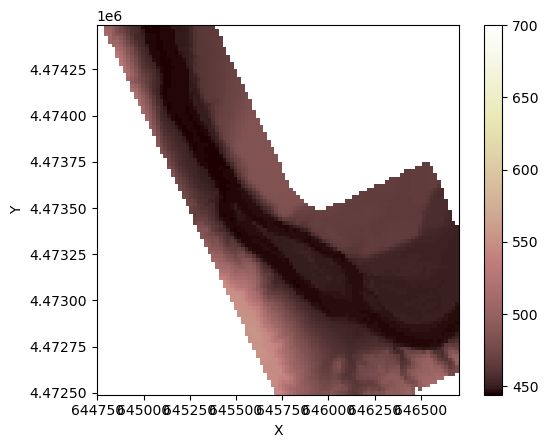

In [5]:
# Showing the topography
imshow_grid(grid, "topographic__elevation")

Our channel is empty at the beginning of the simulation, so we create the proper fields:

In [6]:
# We establish the initial conditions, which represent an empty channel
h = grid.add_zeros("surface_water__depth", at="node")

# Water velocity is zero in everywhere since there is no water yet
vel = grid.add_zeros("surface_water__velocity", at="link")

# Calculating the initial water surface elevation from water depth and topographic elevation
wse = grid.add_zeros("surface_water__elevation", at="node")
wse += h + te

Then, we specify the nodes at which water is entering into the domain, and also their associated links. These are going to be our entry boundary conditions for water depth and flow velocity. In this case, water flows from right to left:

In [7]:
# We set fixed boundary conditions, specifying the nodes and links in which the water is flowing into the grid
fixed_entry_nodes = grid.nodes_at_right_edge
fixed_entry_links = grid.links_at_node[fixed_entry_nodes][:, 2]


In [8]:
# We set the fixed values in the entry nodes/links
# (Average discharge 247 m3/s and water depth of 5.4559 m in the thalweg)
thalweg = grid.at_node["topographic__elevation"][fixed_entry_nodes].min()
WSE = thalweg + 2.4559
entry_nodes_h_values = WSE - grid.at_node["topographic__elevation"][fixed_entry_nodes]
entry_nodes_h_values = np.where(entry_nodes_h_values < 0, 0, entry_nodes_h_values)
tempB1 = (entry_nodes_h_values > 0)
tempCalc1 = np.where(tempB1 == True, entry_nodes_h_values, 1)
entry_links_vel_values = np.where(tempB1 == True, -(247/(grid.dx*np.sum(tempB1)))*(1/tempCalc1), 0)

Now we plot our entry boundary condition in the cross-section:

In [9]:
grid.nodes_at_right_edge

array([  97,  195,  293,  391,  489,  587,  685,  783,  881,  979, 1077,
       1175, 1273, 1371, 1469, 1567, 1665, 1763, 1861, 1959, 2057, 2155,
       2253, 2351, 2449, 2547, 2645, 2743, 2841, 2939, 3037, 3135, 3233,
       3331, 3429, 3527, 3625, 3723, 3821, 3919, 4017, 4115, 4213, 4311,
       4409, 4507, 4605, 4703, 4801, 4899, 4997, 5095, 5193, 5291, 5389,
       5487, 5585, 5683, 5781, 5879, 5977, 6075, 6173, 6271, 6369, 6467,
       6565, 6663, 6761, 6859, 6957, 7055, 7153, 7251, 7349, 7447, 7545,
       7643, 7741, 7839, 7937, 8035, 8133, 8231, 8329, 8427, 8525, 8623,
       8721, 8819, 8917, 9015, 9113, 9211, 9309, 9407, 9505, 9603, 9701,
       9799])

In [10]:
fixed_entry_nodes

array([  97,  195,  293,  391,  489,  587,  685,  783,  881,  979, 1077,
       1175, 1273, 1371, 1469, 1567, 1665, 1763, 1861, 1959, 2057, 2155,
       2253, 2351, 2449, 2547, 2645, 2743, 2841, 2939, 3037, 3135, 3233,
       3331, 3429, 3527, 3625, 3723, 3821, 3919, 4017, 4115, 4213, 4311,
       4409, 4507, 4605, 4703, 4801, 4899, 4997, 5095, 5193, 5291, 5389,
       5487, 5585, 5683, 5781, 5879, 5977, 6075, 6173, 6271, 6369, 6467,
       6565, 6663, 6761, 6859, 6957, 7055, 7153, 7251, 7349, 7447, 7545,
       7643, 7741, 7839, 7937, 8035, 8133, 8231, 8329, 8427, 8525, 8623,
       8721, 8819, 8917, 9015, 9113, 9211, 9309, 9407, 9505, 9603, 9701,
       9799])

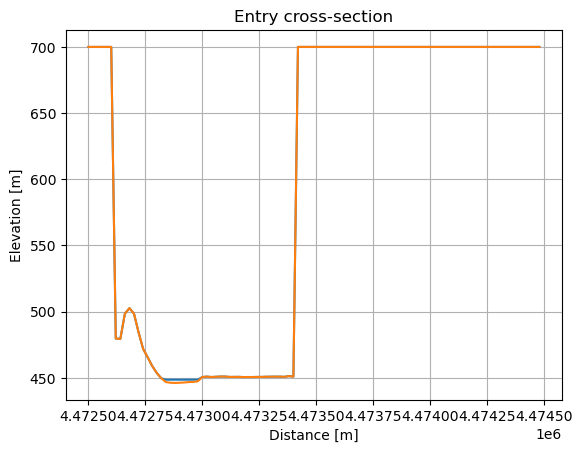

In [11]:
plt.plot(
    grid.y_of_node[fixed_entry_nodes], entry_nodes_h_values + te[fixed_entry_nodes]
)
plt.plot(grid.y_of_node[grid.nodes_at_right_edge], te[grid.nodes_at_right_edge])
plt.title("Entry cross-section")
plt.xlabel("Distance [m]")
plt.ylabel("Elevation [m]")
plt.grid(True)

Checking the initial conditions

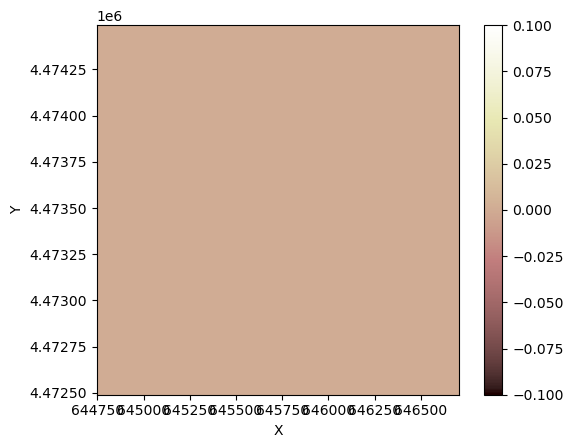

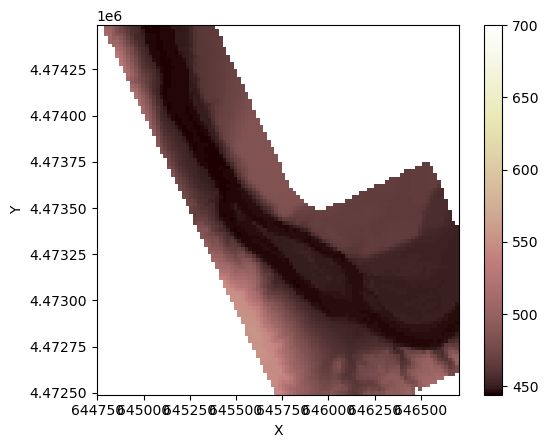

In [12]:
imshow_grid(grid, "surface_water__depth")
plt.show()

imshow_grid(grid, "surface_water__elevation")
plt.show()

Then we create the component with the arguments we defined previously:

In [13]:
# Finally, we run the model and let the water fill our channel
rfd = river_flow_dynamics(
    grid,
    dt=dt,
    mannings_n=n,
    fixed_entry_nodes=fixed_entry_nodes,
    fixed_entry_links=fixed_entry_links,
    entry_nodes_h_values=entry_nodes_h_values,
    entry_links_vel_values=entry_links_vel_values,
)

And we run X time steps of Y seconds duration (around Z minutes of computing time):

In [14]:
for timestep in range(n_timesteps):
    rfd.run_one_step()
    print("[ Current time step: "+str(timestep)+"/"+str(n_timesteps)+" ]")

[ Current time step: 0/1 ]


Exploring the water depth results at the latest time

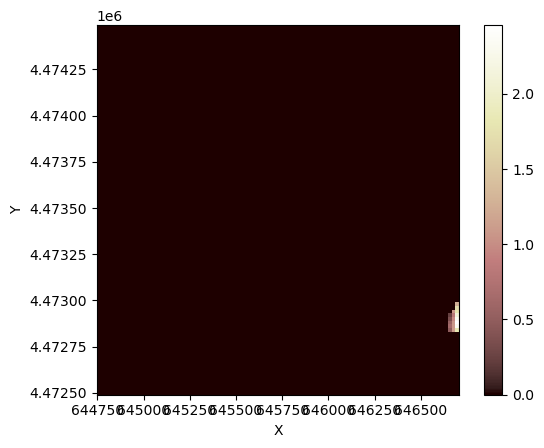

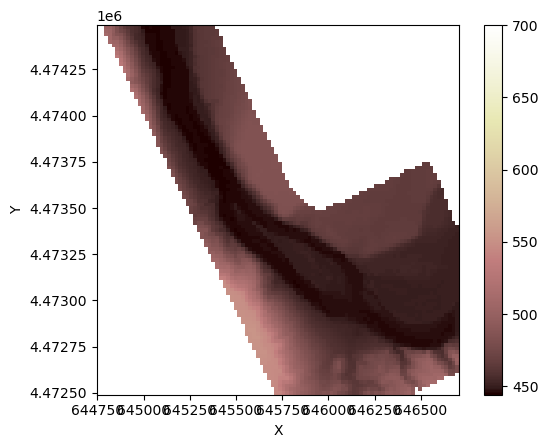

In [15]:
imshow_grid(grid, "surface_water__depth")
plt.show()

imshow_grid(grid, "surface_water__elevation")
plt.show()

In [ ]:
grid.at_node["surface_water__elevation_at_N-1"]

In [ ]:
grid.at_node["surface_water__elevation_at_N-2"]

End